# Minichallenge 2 Notebook 2
Dieses Notbook enthält die Abgaben für die Tage 9 - 15 für die GBSV Minichallenge 2. Der Code sowie die Daten sind in einem GitHub Repository verfügbar und unter diesem Link zu finden: [GitHub Repository](https://github.com/adrianmeier2002/gbsv_minichallenges).

## Tag 9: Use Case
Die mit Abstand beliebteste Sportart in Kanada ist Eishockey. Es ist ein schneller und intensiver Sport, der in Kanada eine lange Tradition hat und tief in der Kultur des Landes verwurzelt ist. Es gibt viele Wechsel während des Spiels, somit ist es wichtig, dass Schiedsrichter und Trainer die Spieler auf dem Eis gut im Blick haben. Eine automatische erkennung der Anzahl an Spielern auf dem Eis könnte dabei helfen, Regelverstösse zu erkennen und Druck bei den Schiedsrichtern zu nehmen.

Als Bild für die Mustererkennung habe ich passend ein Bild der Montreal Canadiens gewählt. Auf dem Bild sind Spieler gut separiert vor dem Tor zu sehen. Es haben alle die gleiche Farbe und sie sind gut separiert voneinander. Somit sollte die Mustererkennung einfacher Funktionieren. Das Bild habe ich auf [A Winning HABIT](https://awinninghabit.com/2019/04/05/montreal-canadiens-roundtable-hope-dwindles-playoffs/) gefunden.


In [20]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from skimage import measure, morphology, color

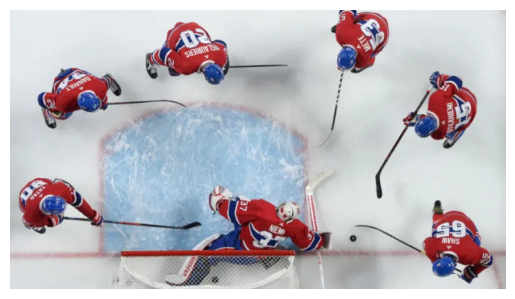

In [21]:
# Visualisieren des Bildes
players = cv2.imread('Images/Players.jpg')
players = cv2.cvtColor(players, cv2.COLOR_BGR2RGB)

plt.imshow(players)
plt.axis('off')
plt.show()

## Tag 10:
Ziel ist es die Spieler auf dem Eis zu erkennen und zu zählen. Dazu Verwende ich zwei verschiedene Ansätzte:

**Otsu Tresholding:**
Dazu wird zuerst ein Gaussfilter angewandt, um das Bild zu glätten und Rauschen zu reduzieren. Anschliessend verwende ich ein Automatisches Tresholding Verfahren (Otsu), um einen Schwellenwert zu bestimmen, der das Bild in Vorder- und Hintergrund trennt. Da die Spieler Dunkler sind als das Eis, muss das Bild anschliessend Invertiert werden.

**Kantenbasierte Segmentierung:**
Hier verwende ich die Canny Edge Detection Methode, um die Kanten im Bild zu erkennen. 

Im Anschluss werden bei beiden Methoden Connected Components Analysis verwendet, um die zusammenhängenden Regionen im binären Bild zu identifizieren und zu zählen. Jede zusammenhängende Region entspricht einem Spieler auf dem Eis.

<span style="background-color:yellow">
Folgender Codeblock wurde geändert, dass verschiedene Kernalgrössen getestet werden können.
</span>

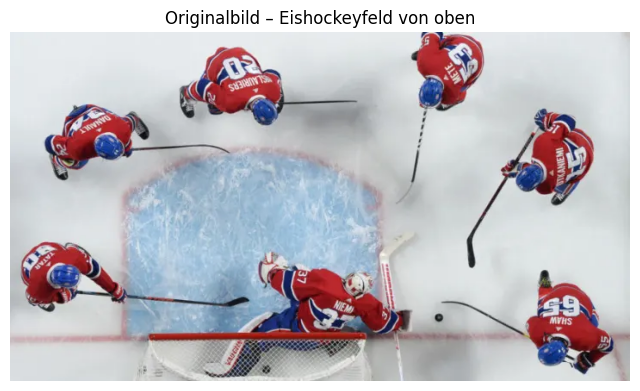


Teste Kernelgrösse: (3, 3)
Gefundene Spieler (Otsu): 65
Gefundene Spieler (Kantenmethode): 249


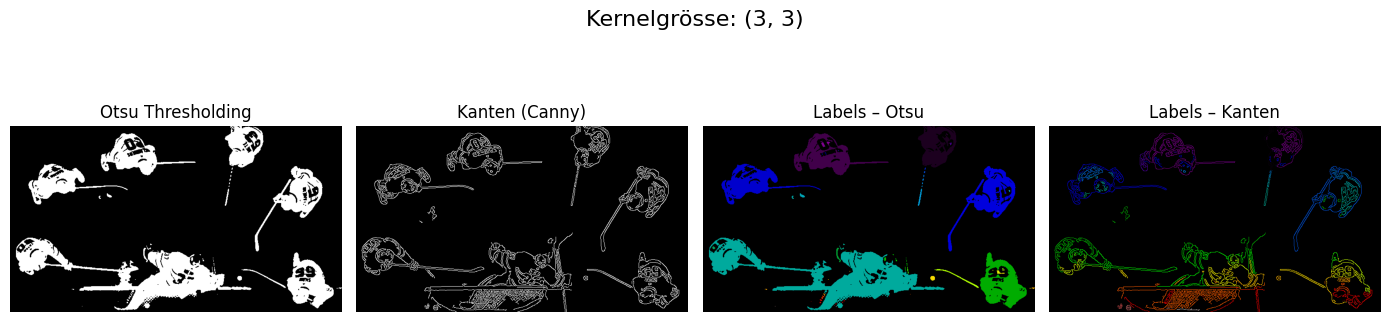


Teste Kernelgrösse: (5, 5)
Gefundene Spieler (Otsu): 47
Gefundene Spieler (Kantenmethode): 204


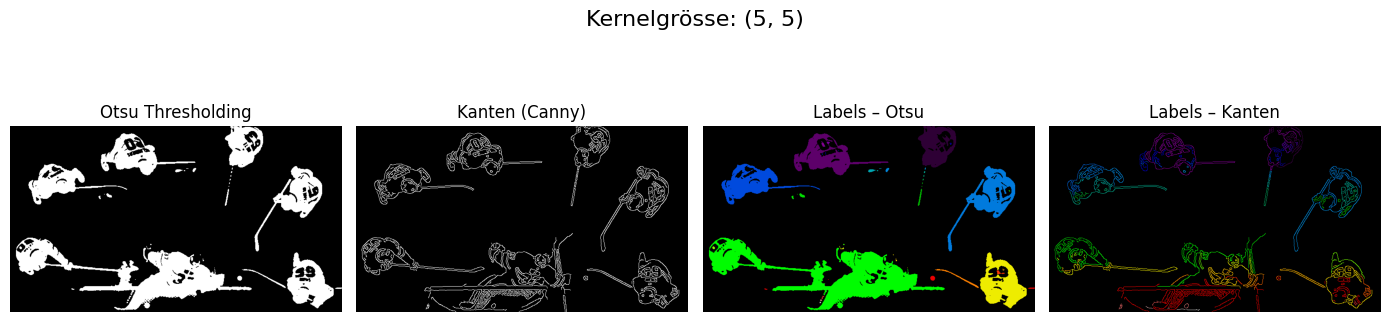


Teste Kernelgrösse: (7, 7)
Gefundene Spieler (Otsu): 33
Gefundene Spieler (Kantenmethode): 171


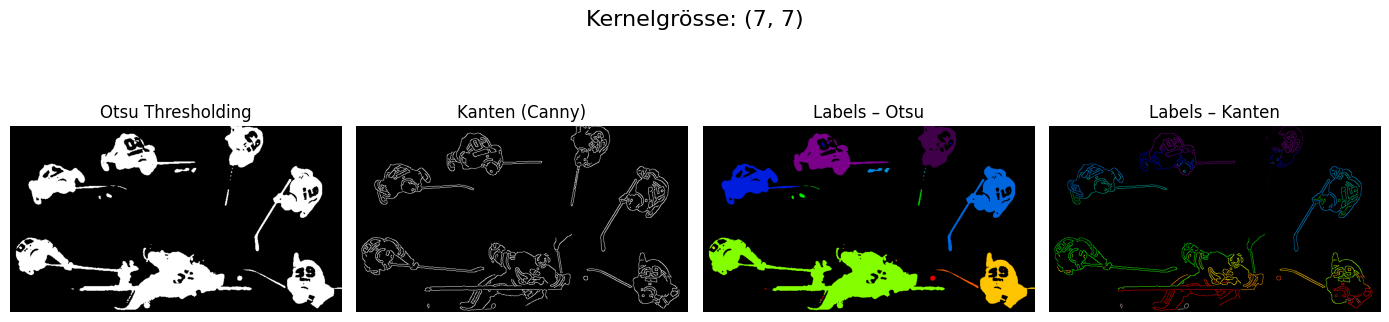


Teste Kernelgrösse: (15, 15)
Gefundene Spieler (Otsu): 17
Gefundene Spieler (Kantenmethode): 75


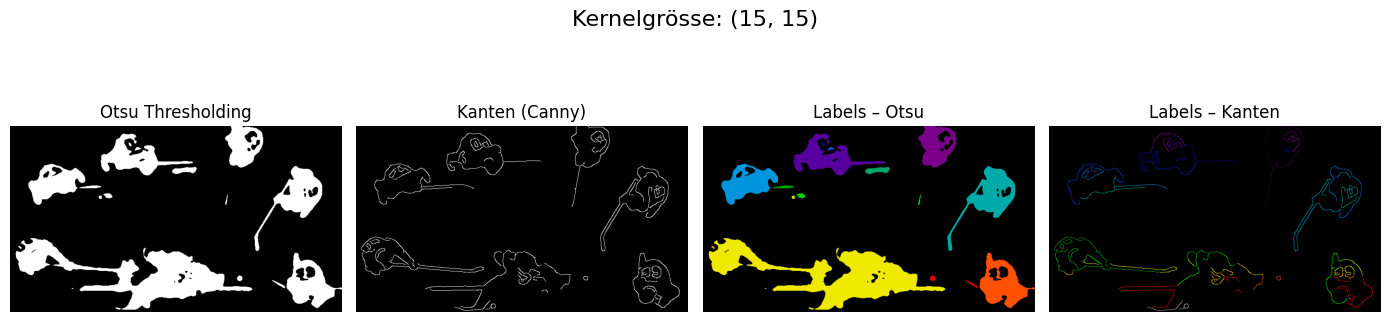

In [22]:
kernel_sizes = [(3,3), (5,5), (7,7), (15,15)]

# --- Bild laden ---
img = cv2.imread('Images/Players.jpg')
if img is None:
    raise FileNotFoundError("Bild nicht gefunden")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Originalbild – Eishockeyfeld von oben")
plt.axis('off')
plt.show()

# ------------------------------------------------------------
# Schleife über verschiedene Kernelgrössen
# ------------------------------------------------------------
for k in kernel_sizes:
    print("\n==============================")
    print(f"Teste Kernelgrösse: {k}")
    print("==============================")

    # --- Methode 1: Otsu Thresholding ---
    blur = cv2.GaussianBlur(img_gray, k, 0)
    _, mask_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # --- Methode 2: Canny-Kanten ---
    edges = cv2.Canny(blur, 50, 150)

    # --- Connected Components ---
    num_labels, labels = cv2.connectedComponents(mask_otsu)
    num_labels_edges, labels_edges = cv2.connectedComponents(edges)

    print(f"Gefundene Spieler (Otsu): {num_labels - 1}")
    print(f"Gefundene Spieler (Kantenmethode): {num_labels_edges - 1}")

    # --- Visualisierung ---
    plt.figure(figsize=(14,4))
    plt.suptitle(f"Kernelgrösse: {k}", fontsize=16)

    plt.subplot(1,4,1)
    plt.imshow(mask_otsu, cmap='gray')
    plt.title("Otsu Thresholding")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Kanten (Canny)")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(labels, cmap='nipy_spectral')
    plt.title("Labels – Otsu")
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(labels_edges, cmap='nipy_spectral')
    plt.title("Labels – Kanten")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Wir sehen dass beide Methoden gundsätzlich den Hintergrund (Eis) vom Vordergrund (Spieler) trennen können. Die Zählung selbst ist jedoch noch nicht gut. Dies wird im nächsten Tag verbessert.

<span style="background-color:yellow">
Bei den unterschiedlichen Kernelgrössen hat sich gezeigt, dass eine grössere Kernelgrösse (z.B. 15x15) viele Deteils verliert, während eine zu kleine Kernelgrösse (z.B. 3x3) zu viel Rauschen im Bild lässt (kleine Flecken im Eis). Eine mittlere Kernelgrösse (z.B. 5x5 oder 7x7) liefert die besten Ergebnisse, da sie eine gute Balance zwischen Rauschunterdrückung und Detailerhaltung bietet.
</span>

## Tag 11: Morphologische Nachbearbeitung
Um die Conected Components Analyse zu verbessern, habe ich eine Morphologische Nachbearbeitung durchgeführt. Dabei werden für die beiden Methoden jeweils unterschiedliche Kernelgrössen verwendet, dies wurde durch ausprobieren ermittelt.

Beim Otsu Tresholding habe ich ein Kernal der Grösse 10x10 verwendet, um dann mithilfe von Opening und Closing kleine Flecken zu entfernen und Lücken zu füllen.

Bei der Kantenbasierten Methode habe ich ein Kernel der Grösse 5x5 verwendet. Dann habe ich mit Dilation die Kanten verbreitert und anschliessend mit Closing Lücken gefüllt.

<span style="background-color:yellow">
Neuer Codeblock um verschiedene Parameterwerte für die Morphologische Nachbearbeitung zu testen.
</span>

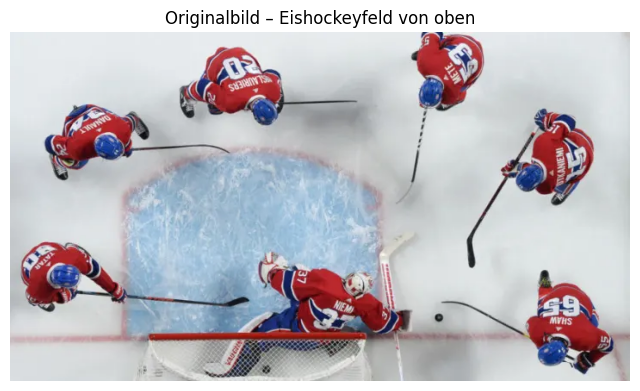


   TEST: OTSU

--- Kernelgrösse OTSU: (3, 3) ---
Gefundene Spieler (Labels) OTSU: 25


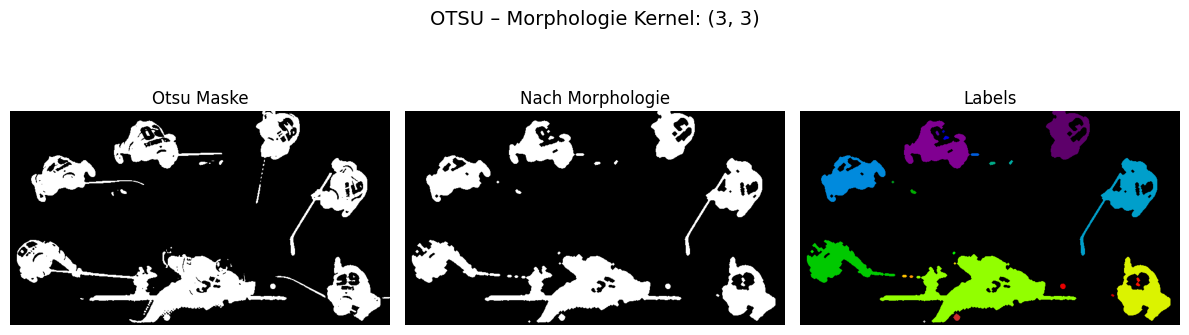


--- Kernelgrösse OTSU: (5, 5) ---
Gefundene Spieler (Labels) OTSU: 12


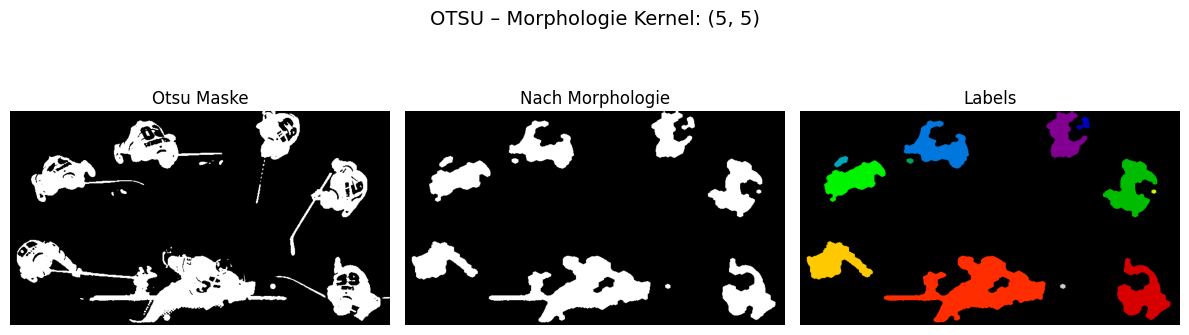


--- Kernelgrösse OTSU: (7, 7) ---
Gefundene Spieler (Labels) OTSU: 8


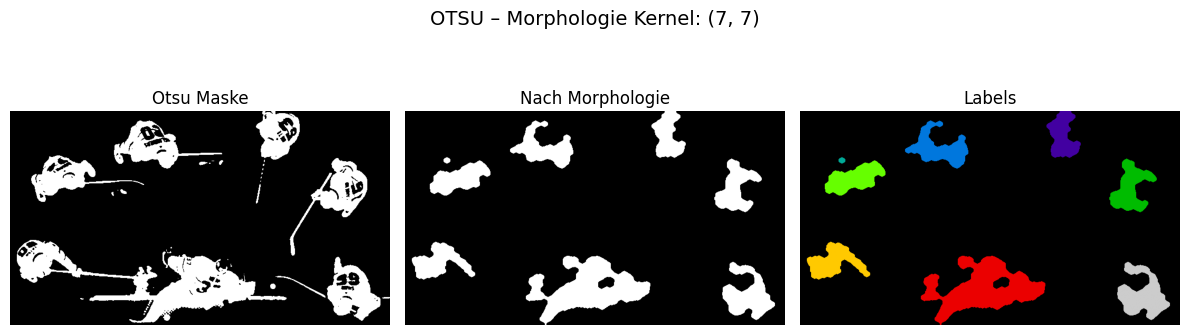


--- Kernelgrösse OTSU: (10, 10) ---
Gefundene Spieler (Labels) OTSU: 7


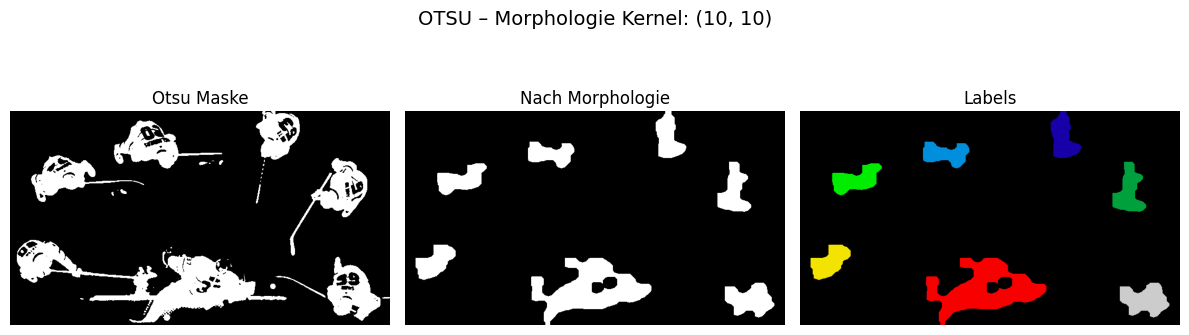


--- Kernelgrösse OTSU: (15, 15) ---
Gefundene Spieler (Labels) OTSU: 7


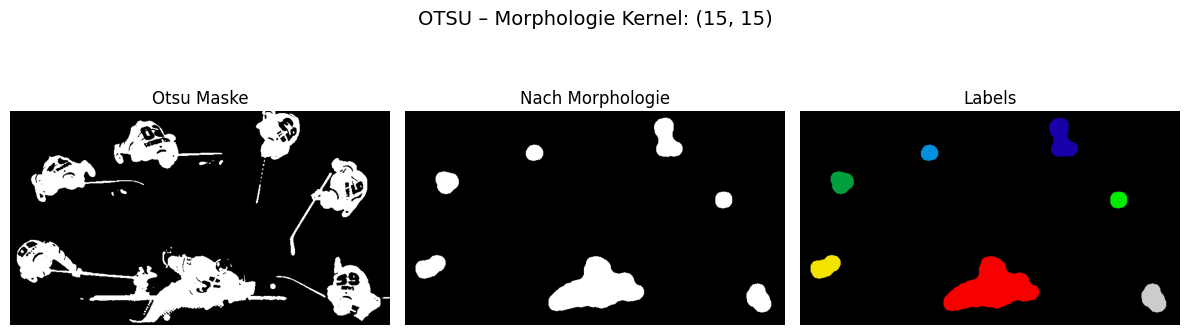


   TEST: CANNY

--- Kernelgrösse CANNY: (3, 3) ---
Gefundene Spieler (Labels) CANNY: 9


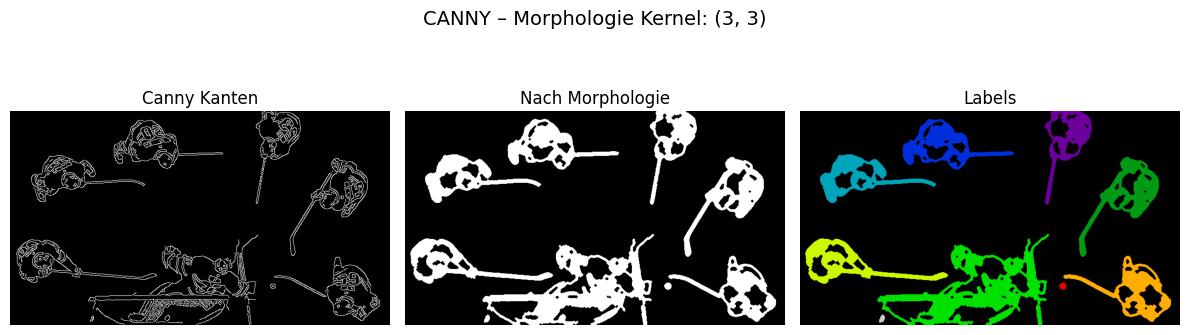


--- Kernelgrösse CANNY: (5, 5) ---
Gefundene Spieler (Labels) CANNY: 7


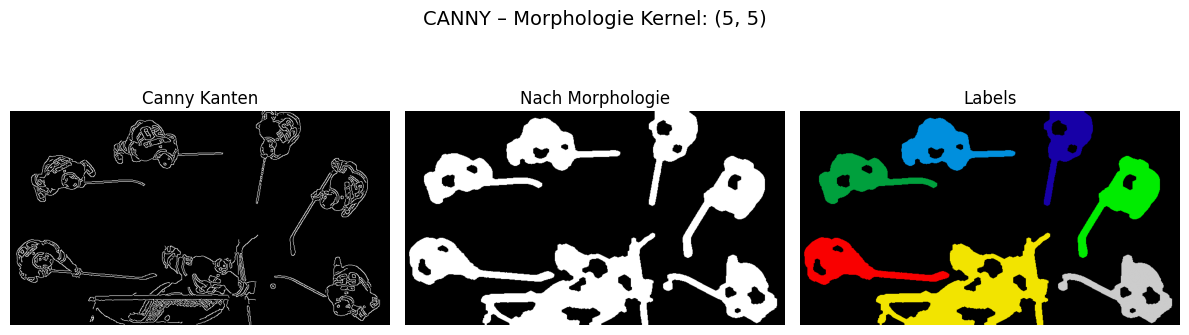


--- Kernelgrösse CANNY: (7, 7) ---
Gefundene Spieler (Labels) CANNY: 6


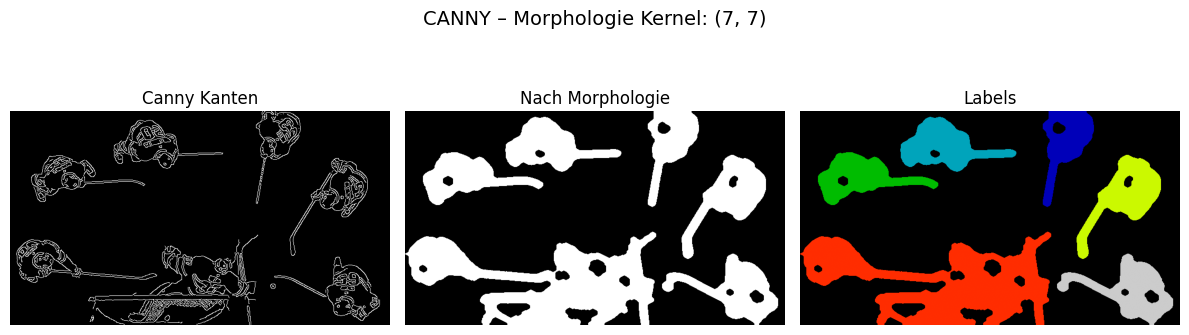


--- Kernelgrösse CANNY: (10, 10) ---
Gefundene Spieler (Labels) CANNY: 4


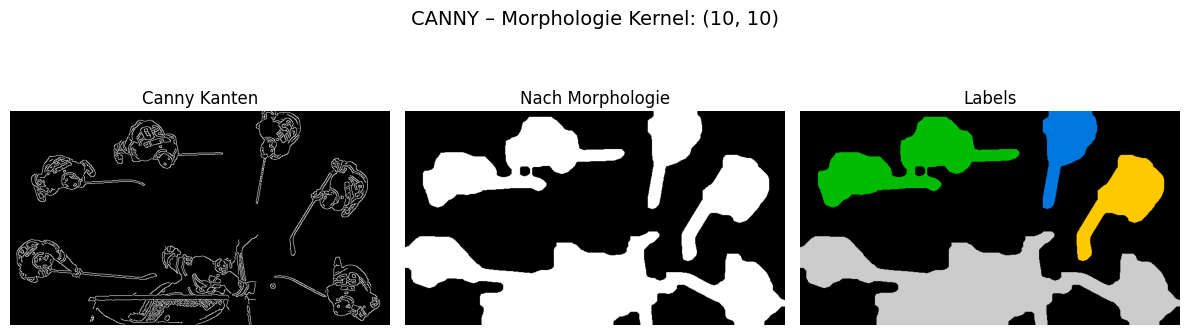


--- Kernelgrösse CANNY: (15, 15) ---
Gefundene Spieler (Labels) CANNY: 3


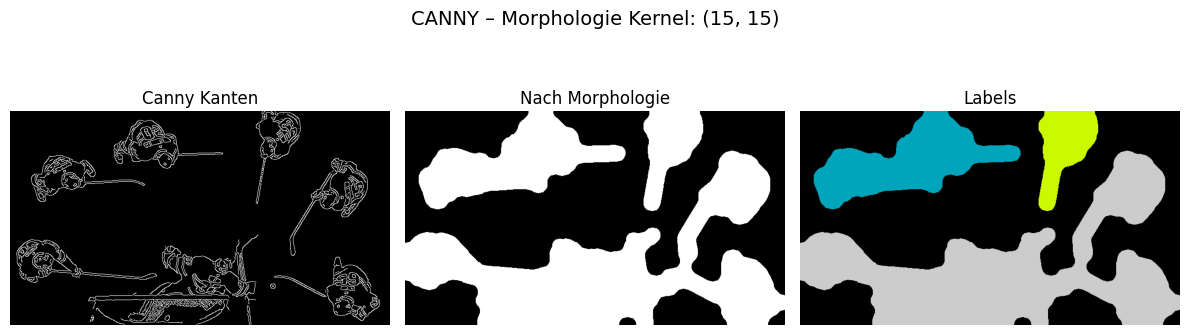

In [23]:
morph_kernels = [(3,3), (5,5), (7,7), (10,10), (15,15)]

# --- Bild laden ---
img = cv2.imread('Images/Players.jpg')
if img is None:
    raise FileNotFoundError("Bild nicht gefunden")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Originalbild – Eishockeyfeld von oben")
plt.axis('off')
plt.show()

# --- Blurring (Fix auf 5x5, da beste Ergebnisse) ---
blur = cv2.GaussianBlur(img_gray, (5,5), 0)

# ===============================================================
#               TEST 1 – OTSU: Morphologie-Kernel variieren
# ===============================================================
print("\n======================")
print("   TEST: OTSU")
print("======================")

for k in morph_kernels:
    print(f"\n--- Kernelgrösse OTSU: {k} ---")

    # Threshold
    _, mask_otsu = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Morphologie
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, k)
    mask_clean = cv2.morphologyEx(mask_otsu, cv2.MORPH_OPEN, kernel, iterations=2)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Connected Component Count
    num_labels, labels = cv2.connectedComponents(mask_clean)
    print(f"Gefundene Spieler (Labels) OTSU: {num_labels - 1}")

    # Visualisierung
    plt.figure(figsize=(12,4))
    plt.suptitle(f"OTSU – Morphologie Kernel: {k}", fontsize=14)

    plt.subplot(1,3,1)
    plt.imshow(mask_otsu, cmap='gray')
    plt.title("Otsu Maske")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask_clean, cmap='gray')
    plt.title("Nach Morphologie")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(labels, cmap='nipy_spectral')
    plt.title("Labels")
    plt.axis('off')

    plt.tight_layout()
    plt.show()



# ===============================================================
#               TEST 2 – CANNY: Morphologie-Kernel variieren
# ===============================================================
print("\n======================")
print("   TEST: CANNY")
print("======================")

for k in morph_kernels:
    print(f"\n--- Kernelgrösse CANNY: {k} ---")

    # Canny Kanten
    edges = cv2.Canny(blur, 50, 150)

    # Morphologie
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, k)
    edges_dilated = cv2.dilate(edges, kernel, iterations=2)
    edges_filled = cv2.morphologyEx(edges_dilated, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Connected Component Count
    num_labels_edges, labels_edges = cv2.connectedComponents(edges_filled)
    print(f"Gefundene Spieler (Labels) CANNY: {num_labels_edges - 1}")

    # Visualisierung
    plt.figure(figsize=(12,4))
    plt.suptitle(f"CANNY – Morphologie Kernel: {k}", fontsize=14)

    plt.subplot(1,3,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Canny Kanten")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(edges_filled, cmap='gray')
    plt.title("Nach Morphologie")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(labels_edges, cmap='nipy_spectral')
    plt.title("Labels")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

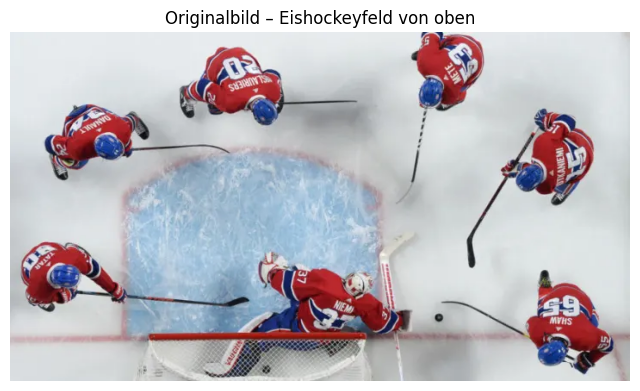

Gefundene Spieler (Labels) mit Otsu: 7
Gefundene Spieler (Labels) mit Kantenmethode: 7


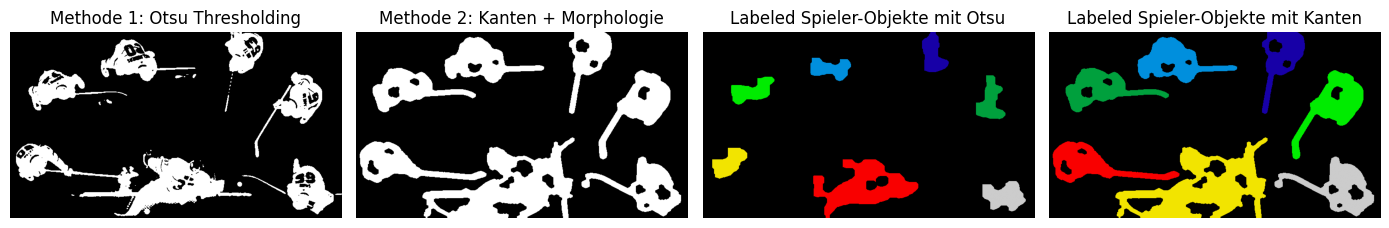

In [24]:
# --- Bild laden ---
img = cv2.imread('Images/Players.jpg')
if img is None:
    raise FileNotFoundError("Bild nicht gefunden")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Originalbild – Eishockeyfeld von oben")
plt.axis('off')
plt.show()

# --- Methode 1: Thresholding / Otsu ---
# Ziel: Spieler (dunkler) vom hellen Eis trennen
blur = cv2.GaussianBlur(img_gray, (5,5), 0)
_, mask_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- Morphologische Nachbearbeitung ---
# Entferne kleine Flecken und fülle Lücken
kernel_otsu = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10,10))
mask_clean = cv2.morphologyEx(mask_otsu, cv2.MORPH_OPEN, kernel_otsu, iterations=2)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel_otsu, iterations=2)

# --- Methode 2: Kantenbasierte Segmentierung ---
edges = cv2.Canny(blur, 50, 150)
kernel_edges = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
edges_dilated = cv2.dilate(edges, kernel_edges, iterations=2)
edges_filled = cv2.morphologyEx(edges_dilated, cv2.MORPH_CLOSE, kernel_edges, iterations=2)

# --- Connected Components (Spieler zählen) ---
num_labels, labels = cv2.connectedComponents(mask_clean)
print(f"Gefundene Spieler (Labels) mit Otsu: {num_labels - 1}")
num_labels_edges, labels_edges = cv2.connectedComponents(edges_filled)
print(f"Gefundene Spieler (Labels) mit Kantenmethode: {num_labels_edges - 1}")

# --- Visualisierung ---
plt.figure(figsize=(14,8))
plt.subplot(1,4,1)
plt.imshow(mask_otsu, cmap='gray')
plt.title("Methode 1: Otsu Thresholding")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(edges_filled, cmap='gray')
plt.title("Methode 2: Kanten + Morphologie")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Labeled Spieler-Objekte mit Otsu")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(labels_edges, cmap='nipy_spectral')
plt.title("Labeled Spieler-Objekte mit Kanten")
plt.axis('off')

plt.tight_layout()
plt.show()

Als Resultat sieht man, dass die Zählung der Spieler nun bei beiden Methoden korrekt ist. Jedoch ist auch zu sehen das der Detailgrad der Spieler selbst verloren geht, da durch die Morphologische Nachbearbeitung kleine Details entfernt werden. Dies ist vor allem bei der Otsu-Methode der Fall. Dennoch ist dies für die Zählung der Spieler nicht relevant.

<span style="background-color:yellow">
Beim Testen von verschiedenen Kernals für die Morphologische Nachbearbeitung war das Ziel: EIn möglichst kleines Kernal zu finden, welches die Korrekte Zählung der Spieler ermöglicht (7 Spieler). Zu kleine Kernals (z.B. 3x3) konnten dies nicht erreichen und hatten noch zu viele Objekte, während zu grosse Kernals (z.B. 15x15) zu viele Details entfernten und zu wenige zählten. Es hat sich gezeigt, dass für die Otsu-Methode ein Kernal von 10x10 und für die Kantenbasierte Methode ein Kernal von 5x5 die besten Ergebnisse lieferten.
</span>

## Tag 12: Analyse der erkannten Objekte
Ich habe bereits am Tag 10 und 11 mithilfe von Connected Components die Anzahl der Spieler gezählt. Gerade nach der Anwendung der Morphologischen Nachbearbeitung ist die Zählung bei beiden Methoden korrekt. Nun kann man noch die einzelnen Gezählten Objekte betrachten. Dabei habe ich mithilfe von `measure.reagionprops` die Eigenschaften der einzelnen Objekte extrahiert und visualisiert. Dabei habe ich die Bounding Boxen der einzelnen Spieler eingezeichnet, um zu sehen ob die Objekte korrekt erkannt wurden. Ich habe mich dabei für die Kantenbasierte Methode entschieden, da diese mehr Details der Spieler beibehält.

,label,area,bbox_area,extent,solidity,perimeter,equiv_diameter,centroid_row,centroid_col,major_axis,minor_axis,eccentricity
0,1,7177.0,16740,0.428734,0.660501,683.487373,95.593097,57.004180,503.515118,177.277249,81.876621,0.886955
1,2,9339.0,21600,0.432361,0.680784,727.913780,109.044872,65.569333,271.426491,185.582389,89.786080,0.875175
2,3,8444.0,21504,0.392671,0.626549,748.984848,103.688161,124.762316,113.402534,204.655415,83.177685,0.913683
3,4,9970.0,30108,0.331141,0.645684,721.352380,112.668533,159.723069,615.041625,207.540374,96.340692,0.885729
4,5,24353.0,57750,0.421697,0.547714,1991.030663,176.088622,338.547735,334.894181,333.650242,147.122077,0.897533
5,6,9175.0,24750,0.370707,0.573653,848.582828,108.083175,288.957166,95.464196,276.568907,76.236844,0.961257
6,7,9482.0,28080,0.337678,0.550415,914.648845,109.876555,338.150390,627.970892,196.816306,110.856346,0.826288


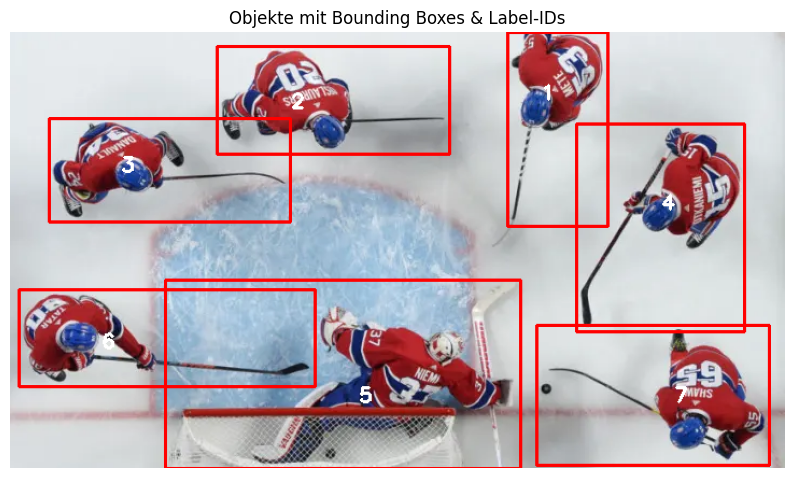

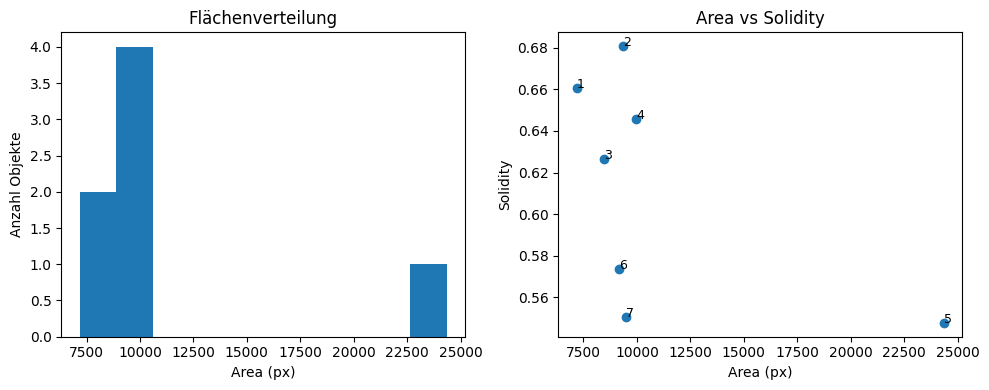

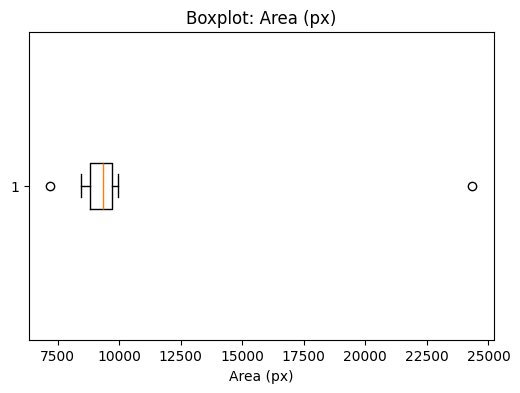

,area,perimeter,equiv_diameter,solidity,eccentricity
count,7.000000,7.000000,7.000000,7.000000,7.000000
mean,11134.285714,948.000103,116.434716,0.612186,0.892374
std,5898.864515,466.956473,26.885522,0.054506,0.040748
min,7177.000000,683.487373,95.593097,0.547714,0.826288
25%,8809.500000,724.633080,105.885668,0.562034,0.880452
50%,9339.000000,748.984848,109.044872,0.626549,0.886955
75%,9726.000000,881.615836,111.272544,0.653092,0.905608
max,24353.000000,1991.030663,176.088622,0.680784,0.961257


In [25]:
# ---------- regionprops-Analyse ----------
props = measure.regionprops(labels_edges, intensity_image=img_gray)

rows = []
for p in props:
    label_id = p.label
    area = p.area
    bbox = p.bbox  # (min_row, min_col, max_row, max_col)
    bbox_area = (bbox[2]-bbox[0]) * (bbox[3]-bbox[1])
    extent = p.extent  # area / bbox_area
    solidity = p.solidity  # area / convex_area
    perimeter = p.perimeter
    equiv_diameter = p.equivalent_diameter
    centroid = p.centroid  # (row, col)
    orientation = p.orientation  # radians (principal axis)
    major_axis_length = p.major_axis_length
    minor_axis_length = p.minor_axis_length
    eccentricity = p.eccentricity
    mean_intensity = p.mean_intensity if hasattr(p, 'mean_intensity') else np.nan

    rows.append({
        'label': label_id,
        'area': area,
        'bbox_area': bbox_area,
        'extent': extent,
        'solidity': solidity,
        'perimeter': perimeter,
        'equiv_diameter': equiv_diameter,
        'centroid_row': centroid[0],
        'centroid_col': centroid[1],
        'major_axis': major_axis_length,
        'minor_axis': minor_axis_length,
        'eccentricity': eccentricity
    })

df = pd.DataFrame(rows)
df = df.sort_values('label').reset_index(drop=True)
display(df)

# ---------- Visualisierung: Bounding boxes & Labels überlagert ----------
img_overlay = img_rgb.copy()
for _, r in df.iterrows():
    # bbox von regionprops braucht das Region-Objekt, dieses wird hier erneut abgerufen
    prop = props[int(r['label']-1)]
    minr, minc, maxr, maxc = prop.bbox
    cv2.rectangle(img_overlay, (minc, minr), (maxc, maxr), (255,0,0), 2)  # rotes Rechteck (RGB)
    c = (int(r['centroid_col']), int(r['centroid_row']))
    cv2.putText(img_overlay, str(int(r['label'])), (c[0]-10, c[1]+5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)

plt.figure(figsize=(10,8))
plt.imshow(img_overlay)
plt.title('Objekte mit Bounding Boxes & Label-IDs')
plt.axis('off')
plt.show()

# ---------- Statistische Analyse & Plots ----------
# 1) Verteilung der Flächen
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['area'], bins=10)
plt.xlabel('Area (px)')
plt.ylabel('Anzahl Objekte')
plt.title('Flächenverteilung')

# 2) Area vs Solidity (Scatter)
plt.subplot(1,2,2)
plt.scatter(df['area'], df['solidity'])
for _, r in df.iterrows():
    plt.text(r['area'], r['solidity'], str(int(r['label'])), fontsize=9)
plt.xlabel('Area (px)')
plt.ylabel('Solidity')
plt.title('Area vs Solidity')
plt.tight_layout()
plt.show()

# 3) Boxplot (Area)
plt.figure(figsize=(6,4))
plt.boxplot(df['area'], vert=False)
plt.title('Boxplot: Area (px)')
plt.xlabel('Area (px)')
plt.show()

# 4) Tabellen-Output: Zusammenfassung
summary = df[['area','perimeter','equiv_diameter','solidity','eccentricity']].describe()
display(summary)

Es werden Folgende Eigenschaften extrahiert und in einem DataFrame dargestellt:
- Label: Eindeutige Kennung für jedes erkannte Objekt.
- Area: Fläche des Objekts in Pixeln.
- bbox Area: Fläche der Bounding Box des Objekts in Pixeln.
- Extent: Verhältnis der Objektfläche zur Fläche der Bounding Box.
- Solidity: Verhältnis der Objektfläche zur Fläche des konvexen Hüllkörpers. Der Konvexe Hüllkörper ist die kleinste konvexe Form, die das Objekt vollständig umschliesst. Dies gibt Aufschluss über die Kompaktheit des Objekts.
- Perimeter: Umfang des Objekts in Pixeln.
- Equivalent Diameter: Durchmesser eines Kreises mit der gleichen Fläche wie das Objekt.
- Centroid: Mittelpunkt des Objekts in Bildkoordinaten (Zeile, Spalte).
- Major Axis: Länge der Hauptachse der Ellipse, die das Objekt am besten beschreibt.
- Minor Axis: Länge der Nebenachse der Ellipse, die das Objekt am besten beschreibt.
- Eccentricity: Mass für die Abweichung der Form des Objekts von einem Kreis (0 = Kreis, 1 = Linie).

Was bei allen Plots auffällt ist, dass alle Spieler bis auf einen Ausreisser ähnliche Eigenschaften haben. Dies ist in diesem Beispiel Logisch. Jeder Spieler hat eine ähnliche Position und Grösse bis auf den Torwart, welcher sich durch seine andere Grösse und Position von den anderen Spielern unterscheidet. Zudem wurde bereits in den Vorherigen Tagen auf den Bildern klar, dass nicht genau unterschieden werden kann, zwischen Torwart und dem Tor. Mann könnte aber mithilfe dieser Metriken Torhüter erkennen, oder auch die Haltung der Spieler analysieren (z.B. ob sie stehen oder liegen).

<span style="background-color:yellow">
Ich habe diese Metriken ausgewählt, da sie eine umfassende Beschreibung der geometrischen und räumlichen Eigenschaften der erkannten Objekte bieten. Diese Metriken ermöglichen es, haltung und Position einer Person zu analysieren, indem sie Informationen über Form, Grösse, Lage und Kompaktheit liefern. Dies ist besonders nützlich, um Unterschiede zwischen verschiedenen Objekten zu erkennen und zu klassifizieren, wie z.B. zwischen Spielern und Torhütern im Eishockey. Mit diesen Metriken und mehr Daten könnte man mithilfe von Machine Learning Modellen die Spieler automatisch klassifizieren und analysieren.
</span>

## Tag 13: Skeletierung

Skelettpixel für Objekt 1: 344


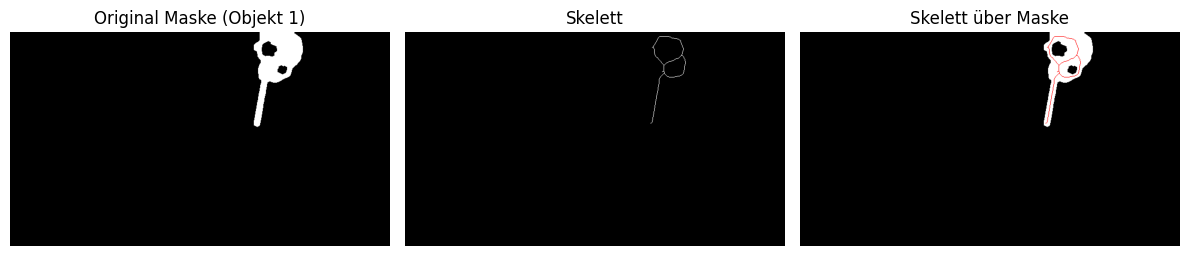

Skelettpixel für Objekt 2: 380


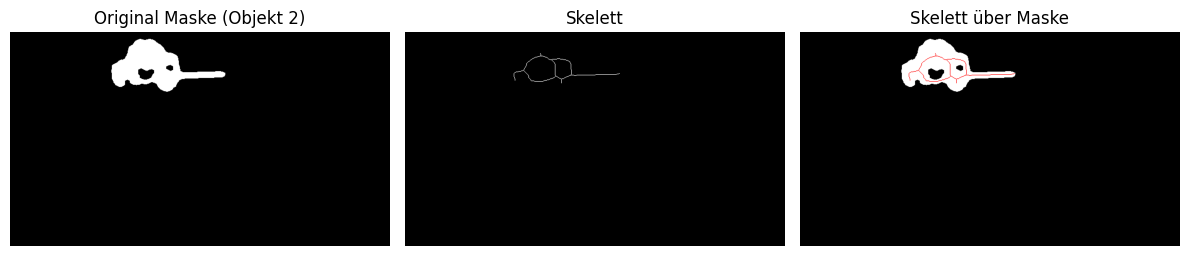

Skelettpixel für Objekt 3: 382


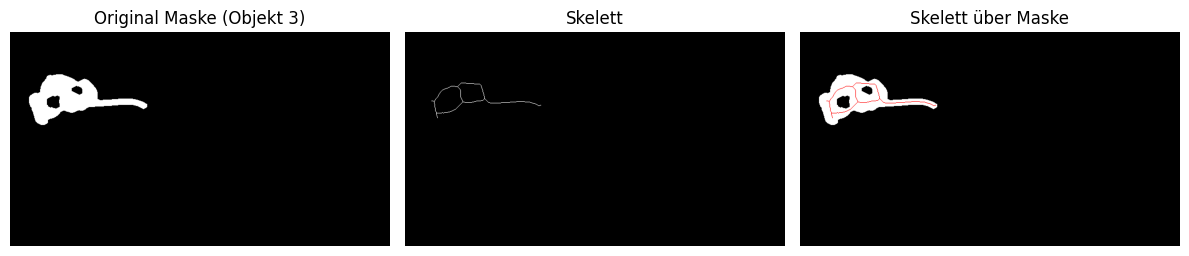

Skelettpixel für Objekt 4: 325


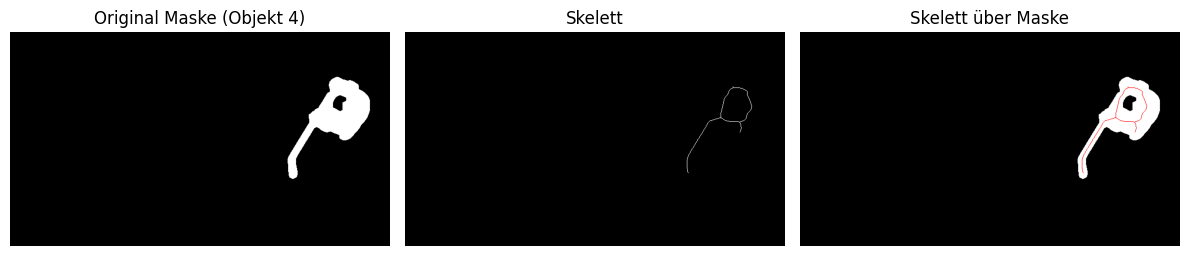

Skelettpixel für Objekt 5: 1166


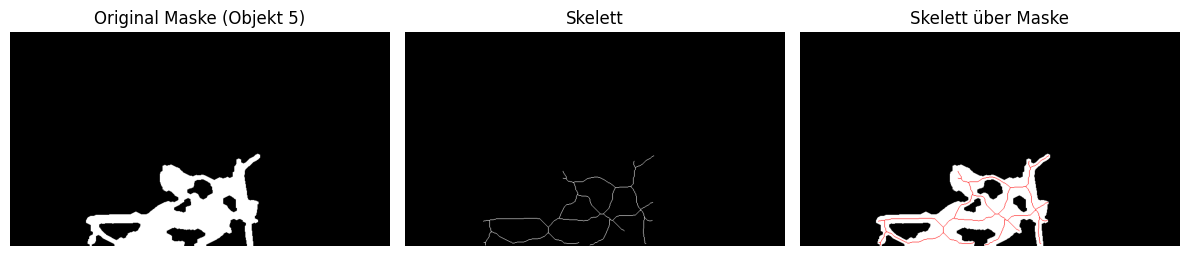

Skelettpixel für Objekt 6: 441


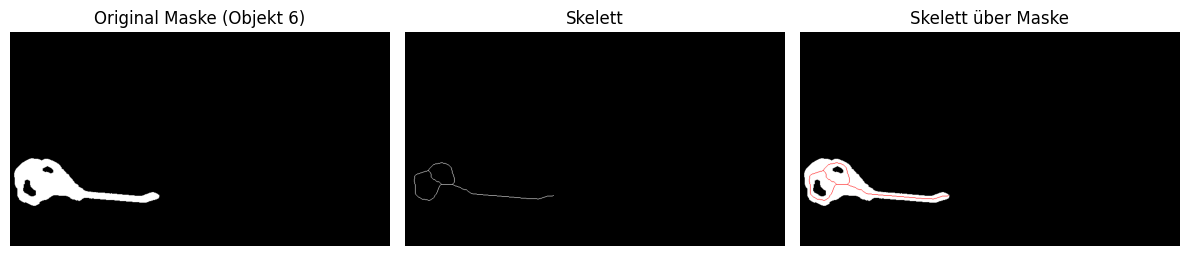

Skelettpixel für Objekt 7: 492


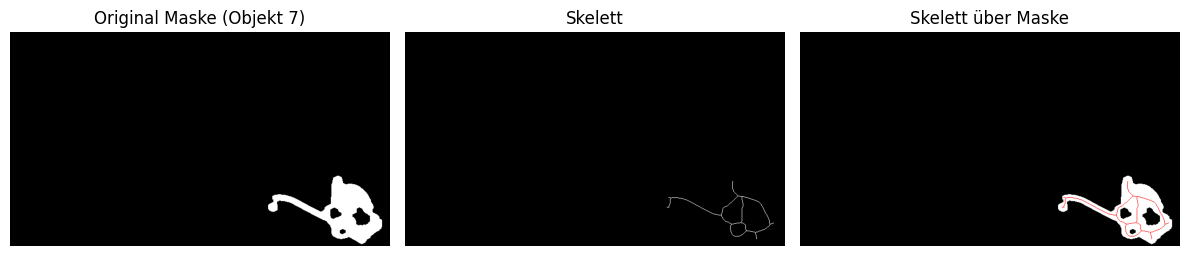

In [26]:
for label_id in range(1, 8):

    object_mask = (labels_edges == label_id).astype(np.uint8)
    
    # Skeletonize mit scikit-image

    skeleton = morphology.skeletonize(object_mask > 0)

    # Anzahl Skelettpixel
    skeleton_pixel_count = np.count_nonzero(skeleton)

    print(f"Skelettpixel für Objekt {label_id}: {skeleton_pixel_count}")

    
    # Visualisierung

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(object_mask, cmap='gray')
    plt.title(f"Original Maske (Objekt {label_id})")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(skeleton, cmap='gray')
    plt.title("Skelett")
    plt.axis('off')

    overlay = np.dstack([object_mask]*3).astype(float)
    overlay = overlay / overlay.max() if overlay.max() > 0 else overlay  # Normalisierung 0–1

    # Färbe Skelettpixel rot
    overlay[skeleton > 0] = [1, 0, 0]  # rot für Skelett

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Skelett über Maske")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Die Skelette für die Spieler wurden erfolgreich erstellt. Man sieht gut, wie die Skelettierung die Form der Spieler wiedergibt. In den meisten fällen ist dies eine 8-Form, welche in der Mitte den gebückten Rücken und Kopf des Spielers darstellt, und die beiden "Kreise" die Arme sind. Zudem ist bei jedem Spieler ein langer Strich zu sehen, welcher den Schläger darstellt. Dies könnte für weitere Analysen nützlich sein, z.B. um die Haltung der Spieler zu analysieren oder um die Position des Schlägers zu verfolgen. Einzig beim Objekt 5, dem Torwart, ist die Skelettierung nicht so klar erkennbar. Dies liegt daran, dass auch im Label das Tor mitenthalten ist, was die Form des Objekts verändert und somit auch die Skelettierung beeinflusst.

## Tag 14: Diskusion der Methoden und Resultate
Beide Methoden, sowohl das Otsu Tresholding als auch die Kantenbasierte Segmentierung, haben gezeigt, dass sie in der Lage sind, die Spieler auf dem Eis zu erkennen und zu zählen. Nach der Morphologischen Nachbearbeitung war die Zählung bei beiden Methoden korrekt. Die Methoden haben in disem Szenario wunderbar Funktioniert, da die Spieler gut separiert und kontrastreich zum Hintergrund sind. In einer realen Anwendung könnten jedoch weitere Herausforderungen auftreten, wie dies bereits beim Torhüter etwas ersichtlich war. Sobald Spieler beispielsweise zusammenprallen oder sich sonst überlappen, könnte die Erkennung schwieriger werden. Zudem ist der Winkel auf dem Bild sehr günstig gewählt, für ein Reales Spiel müssten vielleicht zusätzliche Kamerawinkel verwendet werden. Auch der Hintergrund könnte duch farbige Werbung im Eis oder Zuschauer komplexer sein, was die Segmentierung erschweren könnte. Insgesamt sind beide Methoden jedoch solide Ansätze für die Spielererkennung in diesem Szenario.

## Tag 15: Fazit
Ich habe vieles gelernt in dieser Minichallenge, was ich zwar aus dem alltäglichen kenne, aber nie genau wusste wie es funktioniert. Beispielsweise alles was mit dem Gausschen Filter und der Schärfung zu tun hat. Auch die Morphologische Nachbearbeitung war sehr interessant, da sie eigentlich relativ simpel ist, aber einen grossen Einfluss auf die Resultate hat. Was ich an dieser Minichallenge besonders mochte, war dass man die verschiedenen Methoden jeweils direkt auf ein reales Bild anwenden konnte und so die Resultate direkt sehen konnte. Dies war deutlich erfrischender als nur irgendwelche Kennzahlen zu berechnen und zu optimieren. Es ist zudem auch interresant an gewissen punkten zu sehen, wie man sollche Methoden vielleicht noch weiterentwickeln könnte um sie in der Praxis einzusetzen. Ich hoffe ich werde in Zukunft einmal die Möglichkeit haben, solche Methoden in einem realen Projekt anzuwenden.